# Domain Adaptation: Fine-tuning on Manually Coded Images


**CSV format required:**
```
image_path,emotion_recode2
/path/to/img1.jpg,0
/path/to/img2.jpg,2
```
`emotion_recode2`: 0 = Optimistic · 1 = Pessimistic · 2 = Hostile · 3 = Neutral

Model to adapt is set in `Config.py`.


## 1. Imports & Dependencies

In [1]:
import os
import sys
import time
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import timm
import albumentations as A
from albumentations.pytorch import ToTensorV2
from safetensors.torch import load_file, save_file
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, f1_score,
                             cohen_kappa_score, confusion_matrix,
                             ConfusionMatrixDisplay)
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt


print(f"PyTorch: {torch.__version__}")
print(f"CUDA: {torch.cuda.is_available()}")


PyTorch: 2.11.0+cu128
CUDA: True


## 2. Config

In [2]:
#import custom config
from Config import cfg

In [3]:
#model checkpoint
CHECKPOINT_PATH = "/home/simon/Documents/Zwischen Wörtern und Pixeln/SWIN-Base_checkpoint_final.safetensors" #source checkpoint

#device
device = torch.device(cfg.device)

scfg = cfg.stage_config[cfg.stage]

OUTPUT_DIR = "/home/simon/Documents/Zwischen Wörtern und Pixeln/"

print(f"Stage {cfg.stage}: {scfg['description']}")
print(f"Device  : {device}")
print(f"Output  : {OUTPUT_DIR}")


Stage 2: Head + layers.3 unfrozen
Device  : cuda
Output  : /home/simon/Documents/Zwischen Wörtern und Pixeln/


## 3. Load & Validate Data

In [4]:
def load_and_validate_csv(data_csv, label_col):
    
    df = pd.read_csv(data_csv, low_memory = False)

    required = {"filename", cfg.label_col}
    missing  = required - set(df.columns)
    if missing:
        raise ValueError(f"CSV missing columns: {missing}. Found: {list(df.columns)}")


    #recode labels
    df[label_col] = df[cfg.label_col].replace(
        ["Optimistic",
        "Pessimistic",
        "Hostile",
        "Neutral"],
        [0,
        1,
        2,
        3]
    )

    #force integer
    df[label_col] = df[label_col].astype(int)

    found = set(df[label_col].unique())
    valid = set(range(cfg.num_classes))
    if not found.issubset(valid):
        raise ValueError(f"Unexpected labels: {found - valid}. Expected subset of {valid}.")

    #drop rows with missing image files
    exists_mask = df["filename"].apply(os.path.exists)
    if (~exists_mask).sum() > 0:
        print(f"  Warning: {(~exists_mask).sum()} image(s) not found -> dropping.")
        df = df[exists_mask].reset_index(drop = True)

    return df


def split_data(df, label_col, val_ratio, seed):
    """Stratified split with graceful handling of rare classes."""
    counts      = df[label_col].value_counts()
    rare_labels = counts[counts < 2].index.tolist()
    if rare_labels:
        print(f"  Warning: classes {rare_labels} have < 2 samples -> placed in train only.")
    rare_df   = df[df[label_col].isin(rare_labels)]
    normal_df = df[~df[label_col].isin(rare_labels)]

    train_df, val_df = train_test_split(
        normal_df, test_size = val_ratio,
        stratify = normal_df[label_col], random_state = seed
    )
    train_df = pd.concat([train_df, rare_df], ignore_index = True)
    return train_df.reset_index(drop = True), val_df.reset_index(drop = True)


#run function
df = load_and_validate_csv(cfg.data_csv_adaptation, 
                           cfg.label_col)

print(f"Total coded images: {len(df)}")
print("\nLabel distribution:")

for c in range(cfg.num_classes):
    n   = (df[cfg.label_col] == c).sum()
    pct = n / len(df) * 100
    print(f"  {cfg.EMOTION_NAMES[c]:<14} {n:>4}  ({pct:.1f}%)")

if len(df) < scfg["min_images"]:
    print(f"\n Stage {cfg.stage} recommends ≥{scfg['min_images']} images. "
          f"You have {len(df)}. Consider Stage {max(1, cfg.stage-1)}.")

train_df, val_df = split_data(df, 
                              cfg.label_col, 
                              cfg.val_ratio, 
                              cfg.random_seed)

print(f"\nTrain: {len(train_df)}  |  Val: {len(val_df)}")


Total coded images: 410

Label distribution:
  Optimistic      128  (31.2%)
  Pessimistic      50  (12.2%)
  Hostile          63  (15.4%)
  Neutral         169  (41.2%)

Train: 328  |  Val: 82


## 4. Transforms, MixUp & Dataset

As our dataset for domain adaptation is small, we use heavy augmentation. <br>

In [5]:
def get_transforms(train = True):
    """Heavy augmentation for training.
    Validation: resize + normalise only.
    """
    norm = A.Normalize(mean = cfg.imagenet_mean, std = cfg.imagenet_std)
    if train:
        return A.Compose([
            A.RandomResizedCrop(size = (cfg.img_size, cfg.img_size), scale = (0.65, 1.0)),
            A.HorizontalFlip(p = 0.5),
            A.RandomBrightnessContrast(brightness_limit = 0.35,
                                       contrast_limit = 0.35, p = 0.6),
            A.ColorJitter(brightness = 0.3, contrast = 0.3, saturation = 0.3, p = 0.5),
            A.HueSaturationValue(hue_shift_limit = 15, sat_shift_limit = 25,
                                 val_shift_limit = 15, p = 0.4),
            A.Rotate(limit = 20, p = 0.5),
            A.GaussNoise(p = 0.4),
            A.CoarseDropout(num_holes_range = (1, 1), hole_height_range = (16, 56), hole_width_range = (16, 56), p = 0.5),

            
            norm, ToTensorV2(),
        ])
    return A.Compose([A.Resize(cfg.img_size, cfg.img_size), norm, ToTensorV2()])


class DomainDataset(Dataset):
    
    def __init__(self, df, transform):
        self.df        = df.reset_index(drop =  True)
        self.transform = transform
        
        #use sample_weight column if present, otherwise default to 1.0
        if "sample_weight" in df.columns:
            self.weights = df["sample_weight"].values.astype(float)
            print("Using sample weights")
        
        else:
            self.weights = np.ones(len(df))
            print("Defaulting sample weights to 1.0")

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row    = self.df.iloc[idx]
        image  = cv2.imread(row["filename"])
        image  = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        image  = self.transform(image = image)["image"]
        label  = int(row[cfg.label_col])
        weight = float(self.weights[idx])
        
        return image, label, weight


def build_sampler(train_df):
    counts         = train_df[cfg.label_col].value_counts().to_dict()
    sample_weights = train_df[cfg.label_col].map(lambda c: 1.0 / counts[c])
    
    return WeightedRandomSampler(
        weights = torch.tensor(sample_weights.values, dtype = torch.double), #fp64 precision
        num_samples = len(sample_weights), replacement = True,
    )


def compute_class_weights(train_df, device):
    counts = train_df[cfg.label_col].value_counts().sort_index()
    for c in range(cfg.num_classes):
        if c not in counts.index:
            counts[c] = 1
    counts  = counts.sort_index()
    weights = 1.0 / np.sqrt(counts.values.astype(float))
    weights = weights / weights.sum() * cfg.num_classes
    
    return torch.tensor(weights, dtype = torch.float).to(device)


def mixup_batch(images, labels, alpha, num_classes, device):
    """MixUp: blend image pairs and their one-hot labels."""
    
    if alpha <= 0.0:
        
        return images, F.one_hot(labels, num_classes).float()
    
    lam = np.random.beta(alpha, alpha)
    idx = torch.randperm(images.size(0), device = device)
    mixed_images = lam * images + (1 - lam) * images[idx]
    onehot = F.one_hot(labels, num_classes).float()
    mixed_labels = lam * onehot + (1 - lam) * onehot[idx]
    
    return mixed_images, mixed_labels


#build loaders
train_ds = DomainDataset(train_df, get_transforms(train = True))
val_ds   = DomainDataset(val_df,   get_transforms(train = False))

train_loader = DataLoader(train_ds, batch_size = cfg.batch_size_adaptation,
                          sampler = build_sampler(train_df),
                          num_workers = cfg.num_workers_adaptation, pin_memory = True)
val_loader   = DataLoader(val_ds,   batch_size = cfg.batch_size_adaptation,
                          shuffle = False, num_workers = cfg.num_workers_adaptation, pin_memory = True)

class_weights = compute_class_weights(train_df, device)
print("Class weights:",
      {cfg.EMOTION_NAMES[i]: round(class_weights[i].item(), 3) for i in range(cfg.num_classes)})

# Sanity check
imgs, labels, weights = next(iter(train_loader))
print(f"Batch shape  : {imgs.shape}")
print(f"Labels       : {labels.tolist()[:8]}")
print(f"Sample weights: {weights.tolist()[:8]}")


Using sample weights
Using sample weights
Class weights: {'Optimistic': 0.814, 'Pessimistic': 1.306, 'Hostile': 1.168, 'Neutral': 0.711}
Batch shape  : torch.Size([16, 3, 224, 224])
Labels       : [0, 0, 3, 1, 2, 2, 2, 2]
Sample weights: [2.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]


## 5. Model: Load & Apply Stage Freezing

In [6]:
def load_model(checkpoint_path, device):
    """Load model from .safetensors checkpoint."""
    print(f"Loading: {checkpoint_path}")
    model = timm.create_model(
        cfg.model_name, 
        pretrained = False, #use checkpoint instead of pretrained
        num_classes = cfg.num_classes,
        drop_rate = cfg.drop_rate, 
        drop_path_rate = cfg.drop_path_rate,
    )

    #load state dict with cpu for compatibility reasons
    #is later pushed to gpu
    state_dict = load_file(checkpoint_path, device = "cpu")
    missing, unexpected = model.load_state_dict(state_dict, strict = True)
    if missing: print(f"  Missing keys    : {missing}")
    if unexpected: print(f"  Unexpected keys : {unexpected}")
    
    return model.to(device)


def apply_stage(model, stage):
    scfg = cfg.stage_config[stage]

    #start fully frozen
    for p in model.parameters():
        p.requires_grad = False

    #always unfreeze the classification head
    for p in model.head.parameters():
        p.requires_grad = True

    #unfreeze specified layers, exact prefix match prevents
    #"layers.2" from accidentally matching "layers.20" etc.
    for prefix in scfg["unfreeze_layers"]:
        for name, p in model.named_parameters():
            if name == prefix or name.startswith(prefix + "."):
                p.requires_grad = True

    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total     = sum(p.numel() for p in model.parameters())
    print(f"Stage {stage}: {scfg['description']}")
    print(f"Trainable: {trainable:,} / {total:,}  ({trainable/total*100:.4f}%)")
    print(f"Unfrozen prefixes: {scfg['unfreeze_layers']}")


def build_optimizer(model, stage):
    scfg        = cfg.stage_config[stage]
    head_params = [p for p in model.head.parameters() if p.requires_grad]
    bb_params   = [p for n, p in model.named_parameters()
                   if p.requires_grad and not n.startswith("head")]
    groups = [{"params": head_params, "lr": scfg["lr_head"]}]
    if bb_params:
        groups.append({"params": bb_params, "lr": scfg["lr_backbone"]})
    
    return torch.optim.AdamW(groups, cfg.weight_decay_adaptation, betas = (0.9, 0.999))


#build
model = load_model(CHECKPOINT_PATH, device)

apply_stage(model, cfg.stage)

optimizer = build_optimizer(model, cfg.stage)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, 
    T_max = scfg["epochs"]
)

criterion = nn.CrossEntropyLoss(weight = class_weights, reduction = "mean", label_smoothing = cfg.label_smoothing_adaptation)

scaler = torch.amp.GradScaler("cuda", enabled = (device.type == "cuda"))

print("Model ready.")


Loading: /home/simon/Documents/Zwischen Wörtern und Pixeln/SWIN-Base_checkpoint_final.safetensors
Stage 2: Head + layers.3 unfrozen
Trainable: 27,308,612 / 86,747,324  (31.4806%)
Unfrozen prefixes: ['layers.3']
Model ready.


## 6. Training & Validation Functions

In [7]:
def train_one_epoch(model,
                    loader,
                    optimizer,
                    criterion,
                    scaler,
                    device):
    
    model.train()
    
    total_loss = 0.0

    for images, labels, weights in loader:
        images  = images.to(device)
        labels  = labels.to(device)
        weights = weights.to(device).float()

        optimizer.zero_grad()

        with torch.amp.autocast("cuda", enabled = (device.type == "cuda")):
            
            if cfg.mixup_alpha_adaptation > 0.0:
                images, soft_labels = mixup_batch(
                    images, labels, cfg.mixup_alpha_adaptation, cfg.num_classes, device
                )
                outputs = model(images)
                
                #soft CE per sample, then apply sample weights
                log_prob = F.log_softmax(outputs, dim = 1)
                ce_per_sample = -(soft_labels * log_prob).sum(dim = 1)
                loss = (ce_per_sample * weights).mean()

            else:
                outputs = model(images)
                
                #hard CE per sample, then apply sample weights
                ce_per_sample    = F.cross_entropy(
                    outputs, labels,
                    weight    = criterion.weight,   # class weights still applied
                    reduction = "none",
                )
                loss             = (ce_per_sample * weights).mean()

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer)
        scaler.update()
        total_loss += loss.item()

    return total_loss / len(loader)


@torch.no_grad()
def validate(model, loader, criterion, device):
    
    model.eval()
    
    total_loss = 0.0
    all_preds, all_labels = [], []

    for images, labels, _ in loader:   #discard weights during validation by using _
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        total_loss += F.cross_entropy(
            outputs, labels, weight = criterion.weight
        ).item()
        all_preds.extend(outputs.argmax(1).cpu().tolist())
        all_labels.extend(labels.cpu().tolist())

    val_loss = total_loss / len(loader)
    val_acc  = sum(p == l for p, l in zip(all_preds, all_labels)) / len(all_labels)
    macro_f1 = f1_score(all_labels, all_preds, average = "macro", zero_division = 0)
    
    return val_loss, val_acc, macro_f1, all_labels, all_preds

print("Functions defined.")


Functions defined.


## 7. Training Loop

Runs for up to `epochs` iterations with early stopping (patience from stage config).
The best checkpoint is kept in memory and saved at the end.


In [8]:
best_val_loss = float("inf")
best_macro_f1 = 0.0
best_labels = []
best_preds = []
best_state  = None
epochs_no_improve = 0
history  = []
t0  = time.time()

print(f"{'-' * 60}")
print(f"Stage {cfg.stage}  |  max epochs = {scfg['epochs']}  |  patience = {scfg['patience']}")
print(f"{'-' * 60}")

for epoch in range(scfg["epochs"]):
    train_loss = train_one_epoch(model, 
                                 train_loader, 
                                 optimizer,
                                 criterion, 
                                 scaler, 
                                 device)
    
    val_loss, val_acc, macro_f1, all_labels, all_preds = validate(
        model, 
        val_loader, 
        criterion, 
        device
    )
    scheduler.step()

    history.append(dict(epoch = epoch, 
                        train_loss = train_loss,
                        val_loss = val_loss, 
                        val_acc = val_acc, 
                        macro_f1 = macro_f1))

    print(f"Epoch {epoch+1:03d}/{scfg['epochs']} | "
          f"train = {train_loss:.4f} | val = {val_loss:.4f} | "
          f"acc = {val_acc:.4f} | F1 = {macro_f1:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_macro_f1 = macro_f1
        best_labels = all_labels
        best_preds = all_preds
        epochs_no_improve = 0
        best_state = {k: v.clone() for k, v in model.state_dict().items()}
        print(f" best saved")
    
    else:
        epochs_no_improve += 1
        
        #stop if patience is reached
        if epochs_no_improve >= scfg["patience"]:
            print(f"\nEarly stopping at epoch {epoch + 1}.")
            break

elapsed = time.time() - t0
print(f"\nDone in {elapsed:.0f}s  |  best val_loss = {best_val_loss:.4f}  "
      f"|  best macro F1 = {best_macro_f1:.4f}")


------------------------------------------------------------
Stage 2  |  max epochs = 80  |  patience = 25
------------------------------------------------------------
Epoch 001/80 | train = 1.6946 | val = 1.1289 | acc = 0.4878 | F1 = 0.4549
 best saved
Epoch 002/80 | train = 1.6678 | val = 1.0756 | acc = 0.5610 | F1 = 0.5391
 best saved
Epoch 003/80 | train = 1.4843 | val = 1.0486 | acc = 0.5610 | F1 = 0.5452
 best saved
Epoch 004/80 | train = 1.3125 | val = 0.9541 | acc = 0.5854 | F1 = 0.5655
 best saved
Epoch 005/80 | train = 1.2000 | val = 0.8955 | acc = 0.5976 | F1 = 0.5914
 best saved
Epoch 006/80 | train = 1.2955 | val = 0.8716 | acc = 0.6220 | F1 = 0.6071
 best saved
Epoch 007/80 | train = 1.2375 | val = 0.8341 | acc = 0.6220 | F1 = 0.6230
 best saved
Epoch 008/80 | train = 1.1998 | val = 0.8093 | acc = 0.6220 | F1 = 0.6076
 best saved
Epoch 009/80 | train = 1.0629 | val = 0.7905 | acc = 0.6463 | F1 = 0.6383
 best saved
Epoch 010/80 | train = 1.0682 | val = 0.7835 | acc = 0.634

## 8. Training Curves

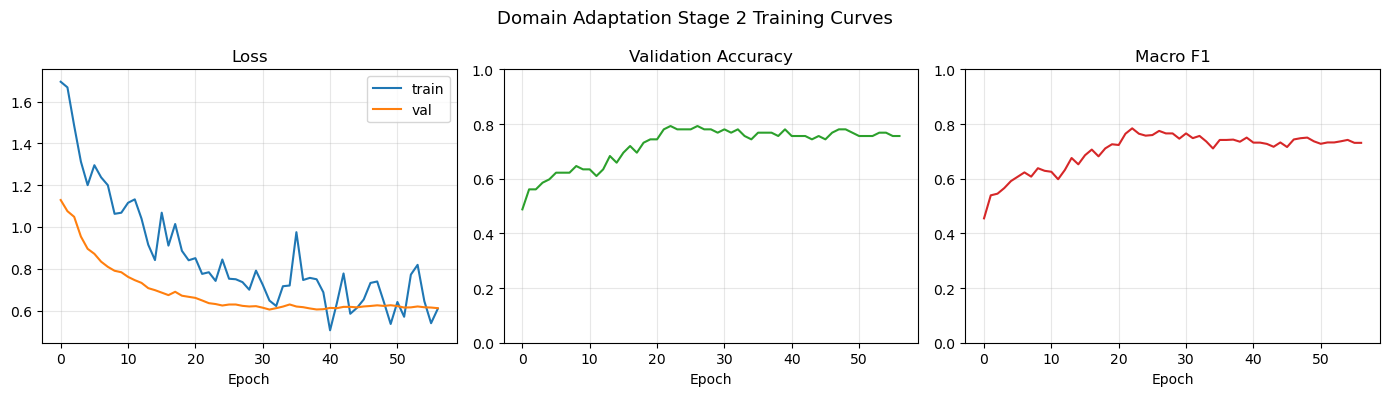

In [9]:
df_h = pd.DataFrame(history)

fig, axes = plt.subplots(1, 3, figsize = (14, 4))

axes[0].plot(df_h["epoch"], df_h["train_loss"], label = "train")
axes[0].plot(df_h["epoch"], df_h["val_loss"],   label = "val")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()
axes[0].grid(True, alpha = 0.3)

axes[1].plot(df_h["epoch"], df_h["val_acc"], color = "C2")
axes[1].set_title("Validation Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylim(0, 1)
axes[1].grid(True, alpha = 0.3)

axes[2].plot(df_h["epoch"], df_h["macro_f1"], color = "C3")
axes[2].set_title("Macro F1")
axes[2].set_xlabel("Epoch")
axes[2].set_ylim(0, 1)
axes[2].grid(True, alpha = 0.3)

fig.suptitle(f"Domain Adaptation Stage {cfg.stage} Training Curves", fontsize = 13)
plt.tight_layout()
plt.savefig("/home/simon/Documents/Zwischen Wörtern und Pixeln/adaptation_stage-1_swin-base_training-curves.svg", dpi = 300, bbox_inches = "tight")
plt.show()


## 9. Final Evaluation

In [10]:
#load best checkpoint
model.load_state_dict(best_state)

print(classification_report(
    best_labels, best_preds,
    target_names = cfg.EMOTION_NAMES, 
    digits = 3, 
    zero_division = 0,
))

kappa = cohen_kappa_score(best_labels, best_preds)
val_acc_final = sum(p == l for p, l in zip(best_preds, best_labels)) / len(best_labels)

print(f"Cohen's Kappa : {kappa:.4f}")
print(f"Macro F1      : {best_macro_f1:.4f}")
print()
print("Kappa interpretation (following Landis & Koch (1977):")
for lo, hi, label in [
    (-1.0, 0.0,  "worse than chance"),
    ( 0.01, 0.20, "slight agreement"),
    ( 0.21, 0.40, "fair agreement"),
    ( 0.41, 0.60, "moderate agreement"),
    ( 0.61, 0.80, "substantial agreement"),
    ( 0.81, 1.00, "almost perfect agreement"),
]:
    marker = "          checkpoint" if lo <= kappa < hi else ""
    print(f"  {lo:+.2f} - {hi:+.2f}  {label}{marker}")


              precision    recall  f1-score   support

  Optimistic      0.826     0.760     0.792        25
 Pessimistic      0.636     0.700     0.667        10
     Hostile      0.714     0.769     0.741        13
     Neutral      0.794     0.794     0.794        34

    accuracy                          0.768        82
   macro avg      0.743     0.756     0.748        82
weighted avg      0.772     0.768     0.769        82

Cohen's Kappa : 0.6686
Macro F1      : 0.7483

Kappa interpretation (following Landis & Koch (1977):
  -1.00 - +0.00  worse than chance
  +0.01 - +0.20  slight agreement
  +0.21 - +0.40  fair agreement
  +0.41 - +0.60  moderate agreement
  +0.61 - +0.80  substantial agreement          checkpoint
  +0.81 - +1.00  almost perfect agreement


## 10. Get mis-classifications

In [11]:
@torch.no_grad()
def get_val_predictions(model, val_df, device):
    """Run inference on the full val set and return a results DataFrame."""
    
    model.eval()
    transform = get_transforms(train = False)
    results   = []

    for _, row in val_df.iterrows():
        image = cv2.imread(row["filename"])
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        tensor = transform(image = image)["image"]
        tensor = tensor.unsqueeze(0).to(device)

        probs  = torch.softmax(model(tensor), dim = 1)[0].cpu()
        pred   = probs.argmax().item()
        conf   = probs[pred].item()
        true   = int(row[cfg.label_col])

        results.append({
            "image_path":   row["filename"],
            "true_label":   cfg.EMOTION_NAMES[true],
            "pred_label":   cfg.EMOTION_NAMES[pred],
            "confidence":   round(conf, 4),
            "correct":      pred == true,
            **{cfg.EMOTION_NAMES[i]: round(probs[i].item(), 4)
               for i in range(cfg.num_classes)},
        })

    return pd.DataFrame(results)


#load best checkpoint
model.load_state_dict(best_state)

preds_df = get_val_predictions(model, val_df, device)
print(f"Total val images : {len(preds_df)}")
print(f"Correct          : {preds_df['correct'].sum()}")
print(f"Misclassified    : {(~preds_df['correct']).sum()}")
preds_df.head()

#save to file
preds_df.to_csv("/home/simon/Documents/Zwischen Wörtern und Pixeln/adaptation_classifications_SWIN-Base.csv",
                encoding = "UTF-8",
                index = False
               )

Total val images : 82
Correct          : 63
Misclassified    : 19


## 11. Confusion Matrix

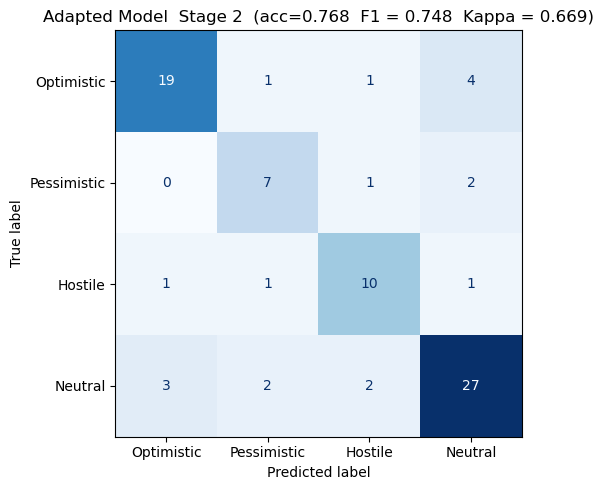

In [12]:
cm = confusion_matrix(best_labels, best_preds)

fig, ax = plt.subplots(figsize = (6, 5))

ConfusionMatrixDisplay(cm, display_labels = cfg.EMOTION_NAMES).plot(
    ax = ax, colorbar = False, cmap = "Blues"
)
ax.set_title(f"Adapted Model  Stage {cfg.stage}  "
             f"(acc={val_acc_final:.3f}  F1 = {best_macro_f1:.3f}  Kappa = {kappa:.3f})")
plt.tight_layout()
plt.savefig("/home/simon/Documents/Zwischen Wörtern und Pixeln/adaptation_stage-1_swin-base_confusion-matrix.svg", dpi = 300, bbox_inches = "tight")
plt.show()


## 12. Save Adapted Model

In [13]:
saved_path = "/home/simon/Documents/Zwischen Wörtern und Pixeln/adaptation_SWIN-Base_checkpoint_final.safetensors"

state_dict = {k: v.contiguous().float() for k, v in model.state_dict().items()}
save_file(state_dict, str(saved_path))

#save training log
pd.DataFrame(history).to_csv("/home/simon/Documents/Zwischen Wörtern und Pixeln/SWIN-Base_training_log.csv", 
                             encoding = "UTF-8",
                             index = False)